# Agentic RAG
🤖 What is Agentic RAG?

Agentic RAG stands for Agentic Retrieval-Augmented Generation — an advanced version of RAG where instead of a static, one-shot LLM response,the system uses an agent that:

- reasons,
- plans,
- retrieves,
- uses tools,
- and even retries or reflects
to generate better, more grounded answers.

# Topics Covered:


### 1. Basic Agentic RAG

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [13]:
from typing import List, Annotated
from pydantic import BaseModel
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display

In [5]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

In [6]:
llm=init_chat_model("openai:gpt-4o")

In [7]:
# -----------------------------
# 1. Document Preprocessing
# -----------------------------
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]

loaders = [WebBaseLoader(url) for url in urls]
docs = []
for loader in loaders:
    docs.extend(loader.load())


print(f"📋 loaded {len(docs)} documents!")
print("="*60)
print(f"Content preview: {docs[0].page_content[0:1000].replace('\n', '')}...")
print("="*60)
print()
print(f"Metadata preview: {docs[0].metadata}")

📋 loaded 2 documents!
Content preview: LLM Powered Autonomous Agents | Lil'LogLil'Log|PostsArchiveSearchTagsFAQ      LLM Powered Autonomous Agents    Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng Table of ContentsAgent System OverviewComponent One: PlanningTask DecompositionSelf-ReflectionComponent Two: MemoryTypes of MemoryMaximum Inner Product Search (MIPS)Component Three: Tool UseCase StudiesScientific Discovery AgentGenerative Agents SimulationProof-of-Concept ExamplesChallengesCitationReferencesBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver....

Metadata preview: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered 

In [8]:
## Recursive character text ssplitter an vectorstore
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(split_docs, embedding)
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [9]:
# the invoke method will give you the documents related to the query
retriever.invoke("What are agents")

[Document(id='55801c81-fa2c-489c-bc91-1521a5fbf1ea', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [10]:
# -----------------------------
# 2. Define RAG State
# -----------------------------
class RAGState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""

In [11]:
# -----------------------------
# 3. LangGraph Nodes
# -----------------------------
def retrieve_docs(state: RAGState) -> RAGState:
    docs = retriever.invoke(state.question)
    return RAGState(question=state.question, retrieved_docs=docs)

def generate_answer(state: RAGState) -> RAGState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"Answer the question based on the context.\n\nContext:\n{context}\n\nQuestion: {state.question}"
    response = llm.invoke(prompt)
    return RAGState(question=state.question, retrieved_docs=state.retrieved_docs, answer= response.content) # type: ignore

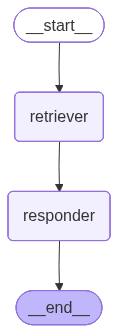

In [15]:
# -----------------------------
# 4. Build LangGraph
# -----------------------------

builder = StateGraph(RAGState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)

builder.set_entry_point("retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
# -----------------------------
# 5. Run the Agentic RAG
# -----------------------------
user_question = "What is the concept of agent loop in autonomous agents?"
initial_state = RAGState(question=user_question)
final_state = graph.invoke(initial_state)
print("\n✅ Final Answer:\n", final_state['answer'])


✅ Final Answer:
 The concept of an agent loop in autonomous agents refers to the iterative cycle in which these agents operate, allowing them to continually assess their environment, make decisions, and take actions based on past experiences and current goals. This loop typically involves components such as memory, planning, and reflection, enabling the agent to adapt and improve over time. Specifically, the self-reflection component allows the agent to refine its actions and correct mistakes, making it highly effective in dynamic, real-world tasks where it learns from trial and error. The integration of a large language model (LLM) enhances these capabilities by allowing the agent to handle complex tasks such as scientific experimentation, where it can browse the Internet, read documentation, execute code, and interact with other systems and agents.


### 2. 🤖 Implement ReAct with LangGraph

ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, StateGraph
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model

In [6]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

In [7]:
# --------------------------
# 1. Create Retriever Tool
# --------------------------

# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [8]:
for doc in retriever.invoke("what are autonomous agents"):
    print(doc.id)
    print("="*60)
    print(f"{doc.page_content[0:1000]}...")

ca360cc2-38b6-45ba-a7a8-52c476d686be
Boiko et al. (2023) also looked into LLM-empowered agents for scientific discovery, to handle autonomous design, planning, and performance of complex scientific experiments. This agent can use tools to browse the Internet, read documentation, execute code, call robotics experimentation APIs and leverage other LLMs.
For example, when requested to "develop a novel anticancer drug", the model came up with the following reasoning steps:...
789a067d-3b2e-427d-8e06-8a4bb19669dc
Citation#
Cited as:

Weng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/....
75cfa643-3d70-486b-9cd7-cab586861b1a
Or
@article{weng2023agent,
  title   = "LLM-powered Autonomous Agents",
  author  = "Weng, Lilian",
  journal = "lilianweng.github.io",
  year    = "2023",
  month   = "Jun",
  url     = "https://lilianweng.github.io/posts/2023-06-23-agent/"
}
References#
[1] Wei et al. “Chain of thought prompting elic

In [9]:
def retriever_tool_func(query: str) -> str:
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

retriever_tool=Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant knowledge base info",
    func=retriever_tool_func
)

print(retriever_tool.name)

RAGRetriever


In [10]:
# Wikipedia tool
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper()) #type: ignore

In [11]:
llm=init_chat_model("openai:gpt-4o")

C:\Users\mrinm\AppData\Local\Temp\ipykernel_31088\1633125191.py:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node=create_react_agent(llm,tools)


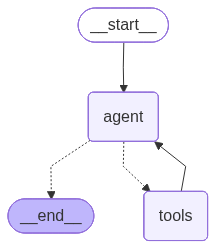

In [12]:
# ----------------------------
# 2. Define the Agent Node
# ----------------------------
tools = [retriever_tool, wiki_tool]
## create the native Langgraph react agent
react_node=create_react_agent(llm,tools)
react_node

In [13]:
# --------------------------
# 3. LangGraph Agent State
# --------------------------
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

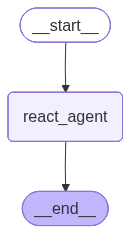

In [14]:
# --------------------------
# 4. Build LangGraph Graph
# --------------------------
builder = StateGraph(AgentState)
builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)
graph = builder.compile()

graph

In [15]:
# --------------------------
# 5. Run the ReAct Agent
# --------------------------
user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
result = graph.invoke({"messages": [HumanMessage(content=user_query)]})
print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using RAGRetriever tool

✅ Final Answer:
 ### Agent Loop
An agent loop involves an autonomous system or an AI agent interacting with its environment, receiving feedback, learning from this interaction, and using that learning to improve future actions. This loop could involve processes like reinforcement learning where the agent improves its performance by optimizing certain outcomes based on prior experiences.

### Autonomous Agents (from Wikipedia)
An autonomous agent is an AI system that can perform complex tasks independently. Wikipedia describes these agents as intelligent entities that perceive their environment, take actions autonomously to achieve goals, and improve their performance through learning or knowledge acquisition.

#### Intelligent Agents
- They are defined by their ability to perceive, decide, and react based on their environment to achieve goals.
- Simple examples are thermostats or control systems, while humans or software systems could be more complex instance

### 3. Tool creation for RAG agents with langgraph 
To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:

- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

#### ✅ Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str

In [21]:
import os
from dotenv import load_dotenv
from langchain_community.tools import Tool, WikipediaQueryRun, ArxivQueryRun
from langchain_core.tools import tool
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader, ArxivLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain.agents import create_agent
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict, Sequence

In [33]:
load_dotenv()

True

In [19]:
llm=init_chat_model("openai:gpt-4o")

In [23]:
## Generic fiunction to create a retriever tool
def make_retriever_tool_from_text(
        file: str,
        name: str,
        desc: str
):
    docs = TextLoader(file, encoding='utf-8').load()

    chunks = RecursiveCharacterTextSplitter(
        chunk_size = 500,
        chunk_overlap = 50
    ).split_documents(docs)

    vs = FAISS.from_documents(chunks, OpenAIEmbeddings())

    retriever = vs.as_retriever()

    @tool(name, description = desc)
    def retriever_tool(query: str):
        """
        Retrieve relavent information from documents.
        """
        print(f"📚 Using tool: {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return retriever_tool


## Wikipedia Tool
wiki_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=500
    )
)

## Arxiv Tool
arxiv_tool = ArxivQueryRun(api_wrapper=ArxivAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=1000
))

In [34]:
internal_tool_1 = make_retriever_tool_from_text(
    "sample_docs.txt", 
    "Internal_Tech_Docs", 
    "Search internal tech documents for proprietary architecture and methods"
)

In [35]:
internal_tool_2 = make_retriever_tool_from_text(
    "research_notes.txt", 
    "Internal_Research_Notes", 
    "Search internal Research notes for experimental results and agent design"
)

In [36]:
internal_tool_1

StructuredTool(name='Internal_Tech_Docs', description='Search internal tech documents for proprietary architecture and methods', args_schema=<class 'langchain_core.utils.pydantic.Internal_Tech_Docs'>, func=<function make_retriever_tool_from_text.<locals>.retriever_tool at 0x00000238D9EE2E80>)

In [37]:
tools = [wiki_tool, arxiv_tool, internal_tool_1, internal_tool_2]

In [38]:
react_node = create_agent(llm, tools=tools)

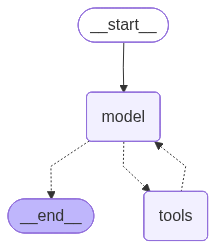

In [39]:
react_node

In [40]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

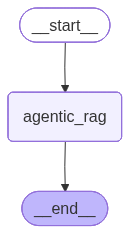

In [41]:
builder = StateGraph(AgentState)

builder.add_node("agentic_rag", react_node)
builder.set_entry_point("agentic_rag")
builder.add_edge("agentic_rag", END)

graph = builder.compile()
graph

In [45]:
query = "What do our internal research notes say about transformer variants, and what does ArXiv suggest recently?"
result = graph.invoke({"messages": HumanMessage(content = query)})
print("\n✅ Final Answer:\n", result['messages'][-1].content)

📚 Using tool: Internal_Research_Notes

✅ Final Answer:
 Here's a summary of findings from our internal research notes and recent ArXiv articles regarding transformer variants:

### Internal Research Notes on Transformer Variants:

1. **EfficientFormer**:
   - Achieved 92.4% top-1 accuracy on TinyImageNet.
   - Peak memory usage: 290MB for batch size 16.
   - Deployment on Raspberry Pi 4 works well, especially in quantized int8 mode.

2. **Longformer**:
   - Evaluated on customer support logs with up to 8192 tokens.
   - Observed high latency (>1.2s per query) in streaming settings; potential improvements with chunk-based hybrid attention.

3. **Reformer**:
   - Encountering issues like bucket collisions and loss spikes.
   - Tried gradient clipping, warmup scheduler, and memory-efficient attention modules to address these issues.

4. **TinyBERT**:
   - Used for classification tasks like support ticket priority tagging, achieving an 87% F1 score.

5. **Recent Experiment Highlights**:
  